In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# If not using colab, please comment this whole block:
# To get started, upload the Data_zip from github to google colab
!unzip -q /content/Data_zip.zip -d /content/
training_labels_dir = '/content/Data/training_labels'
training_images_dir = '/content/Data/training_images'
test_labels_dir = '/content/Data/test_labels'
test_images_dir = '/content/Data/test_images'
training_labels = pd.read_csv(os.path.join(training_labels_dir, 'train.csv'))

# -- Heres where you should stop commenting and uncomment the following--

#If not using the zip file but the directories from github it should be:
# training_images_dir = '../Data/training_images'
# training_labels_dir = '../Data/training_labels'
# test_labels_dir = '../Data/test_labels'
# test_images_dir = '../Data/test_images'
# training_labels = pd.read_csv(os.path.join(training_labels_dir, 'train.csv'))


# This is !important! for tensorflow to be able to read the id column properly:
training_labels['Id'] = training_labels['Id'].astype(str) + '.png'

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split = 0.2,
    rotation_range=10 , # Rotating up to 10 degrees
    width_shift_range=0.1, # Shift left/right by 10%
    height_shift_range=0.1, # Shift up/ down by 10%
    zoom_range=0.1 # Zoom in/out by 10%
)
# Separate generator for validation - NO augmentation, only rescaling
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
train_generator = train_datagen.flow_from_dataframe(
    subset='training',
    dataframe=training_labels,
    directory=training_images_dir,
    x_col='Id',
    y_col='Category',
    target_size=(32,32),
    color_mode='grayscale',
    class_mode='raw',
    batch_size=32
)
val_generator = val_datagen.flow_from_dataframe(
    dataframe=training_labels,
    directory=training_images_dir,
    x_col='Id',
    y_col='Category',
    subset='validation',
    target_size=(32, 32),
    color_mode='grayscale',
    class_mode='raw',
    batch_size=32
)



model = models.Sequential([
    # Input layer + 1st Convolutional Block
    layers.Conv2D(32, (3,3), padding ='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),


    # 2nd Convolutional Block
    layers.Conv2D(64, (3,3), padding ='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Flatten the 2D images into a 1D array for the dense layers
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output layer: 10 neurons for digits 0-9. No activation here because
    # we'll handle it in the loss function.
    layers.Dense(10)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Create Early Stopping (Optional but highly recommended)
# If the validation accuracy doesn't improve for 3 epochs in a row, stop training early!
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True # Automatically loads the best weights at the end
)

# 3. Train with the Callbacks
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25, # We can safely set this higher now
    callbacks=[checkpoint, early_stop] # <--- Add them here
)

Found 13600 validated image filenames.
Found 3400 validated image filenames.
Epoch 1/25
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7562 - loss: 0.7661
Epoch 1: val_accuracy improved from None to 0.79559, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8701 - loss: 0.4094 - val_accuracy: 0.7956 - val_loss: 0.6216
Epoch 2/25
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9527 - loss: 0.1608
Epoch 2: val_accuracy improved from 0.79559 to 0.99529, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9591 - loss: 0.1366 - val_accuracy: 0.9953 - val_loss: 0.0203
Epoch 3/25
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9704 - loss: 0.0911
Epoch 3: val_accuracy did not improve from 0.99529
425/425 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9722 - loss: 0.0897 - val_accuracy: 0

In [7]:
# 1. Load the Test CSV
# Make sure this path matches your test labels folder
test_df = pd.read_csv(os.path.join(test_labels_dir, 'test.csv'))

# IMPORTANT: Save the original integer IDs for the final submission
original_ids = test_df['Id'].copy()

# Fix the Kaggle Trap so Keras can find the images
test_df['Id'] = test_df['Id'].astype(str) + '.png'

# 2. Setup the Test Generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=test_images_dir, # Your local Colab test images folder
    x_col='Id',
    y_col=None,                        # There are no labels!
    target_size=(32, 32),
    color_mode='grayscale',
    class_mode=None,                   # Tells Keras not to expect a y_col
    batch_size=32,
    shuffle=False                      # CRUCIAL: Keeps predictions aligned with the CSV
)

# 3. Generate Predictions
print("Generating predictions...")
# model.predict gives us a matrix of probabilities for all 10 classes
raw_predictions = model.predict(test_generator)

# np.argmax looks at the probabilities for each image and picks the index (class)
# with the highest probability.
predicted_classes = np.argmax(raw_predictions, axis=1)

# 4. Create the Submission File
# Check your Kaggle sample_submission.csv. Usually the columns are 'Id' and whatever the target is called
submission_df = pd.DataFrame({
    'Id': original_ids,          # The original IDs without '.png'
    'category': predicted_classes  # Replace 'category' with the exact column name Kaggle expects
})

# Save to a CSV file without the pandas index column
submission_df.to_csv('advanced_cnn_fixed_submission.csv', index=False)
print("Saved as advanced_cnn_fixed_submission.csv! You can now download this and submit to Kaggle.")

Found 3000 validated image filenames.
Generating predictions...
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Saved as advanced_cnn_fixed_submission.csv! You can now download this and submit to Kaggle.


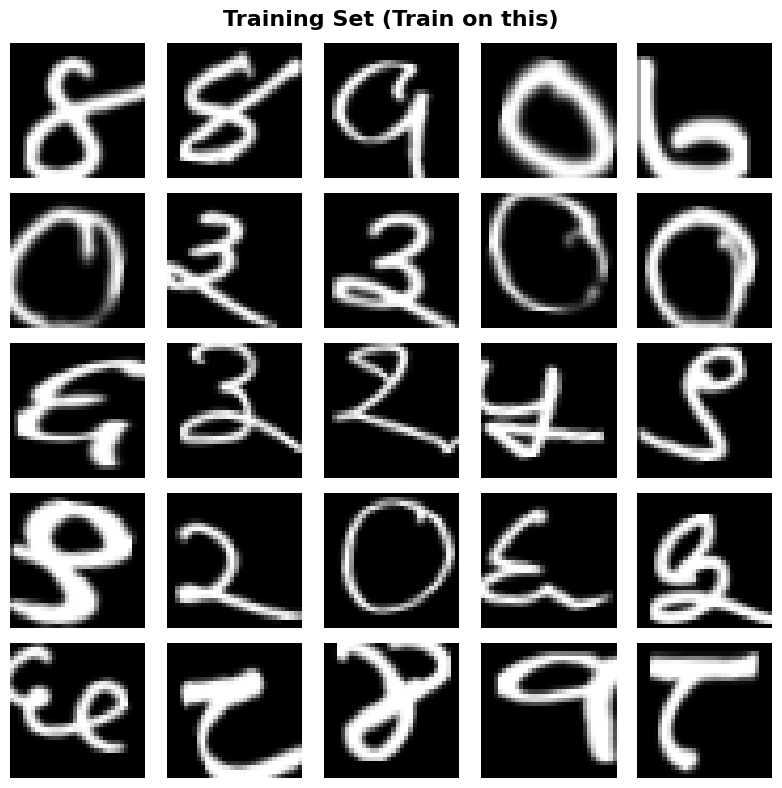

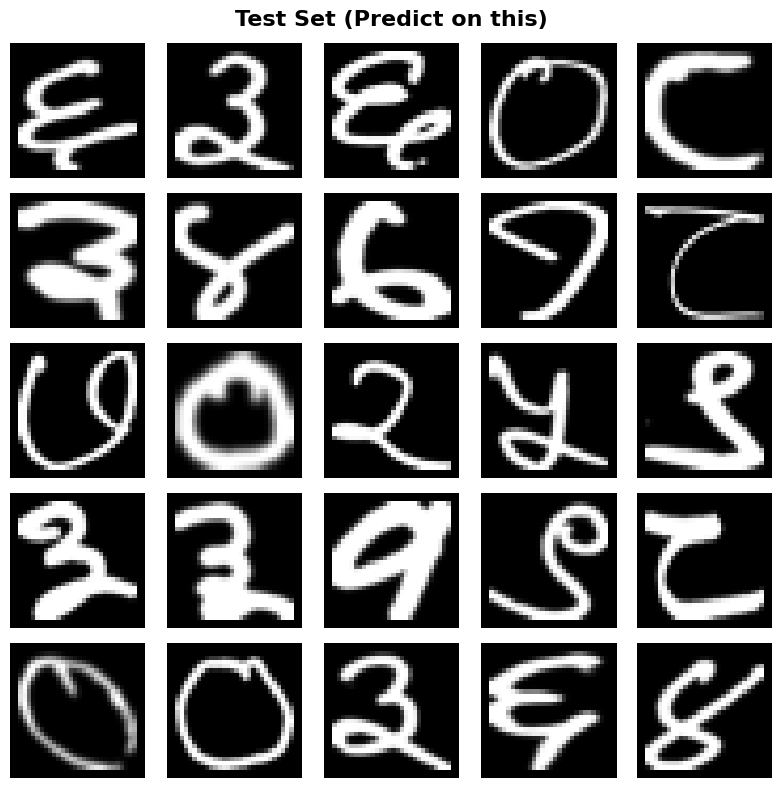

In [8]:
# Grab a single batch (32 images) from both generators
train_images, train_labels = next(iter(train_generator))
test_images = next(iter(test_generator))

def plot_image_grid(images, title):
    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        # We use .squeeze() to drop the 1-channel dimension so matplotlib can plot it
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Plot the grids
plot_image_grid(train_images, "Training Set (Train on this)")
plot_image_grid(test_images, "Test Set (Predict on this)")

In [9]:
# Calculate mean (brightness) and standard deviation (contrast)
train_mean = np.mean(train_images)
train_std = np.std(train_images)

test_mean = np.mean(test_images)
test_std = np.std(test_images)

print("--- Pixel Statistics ---")
print(f"Train Set -> Mean Brightness: {train_mean:.4f} | Contrast (Std): {train_std:.4f}")
print(f"Test Set  -> Mean Brightness: {test_mean:.4f} | Contrast (Std): {test_std:.4f}")

--- Pixel Statistics ---
Train Set -> Mean Brightness: 0.2296 | Contrast (Std): 0.3611
Test Set  -> Mean Brightness: 0.2337 | Contrast (Std): 0.3832


Loading 100% of the Training Set...
Found 17000 validated image filenames.
Loading 100% of the Test Set...
Found 3000 validated image filenames.

Generating Ghost Averages...


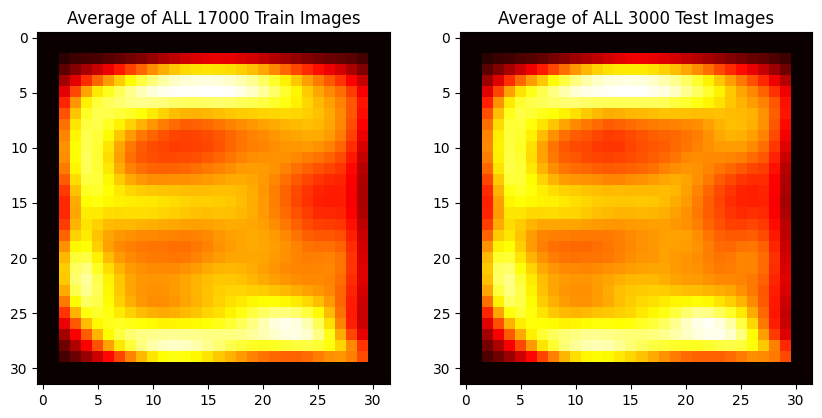


Calculating Stroke Thickness...


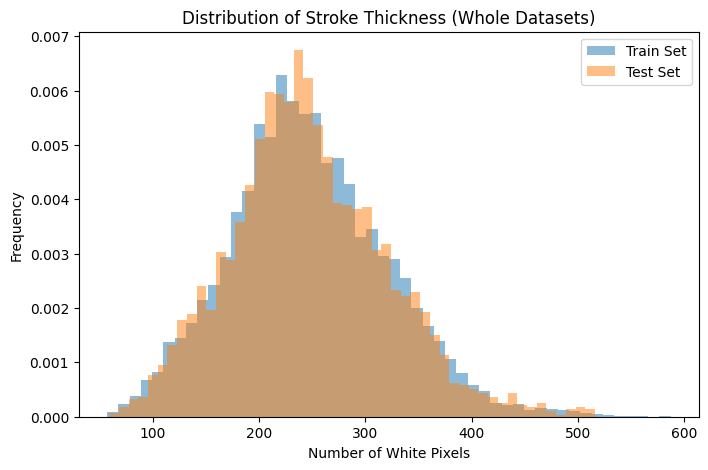


Running PCA on the entire dataset (this might take 5-10 seconds)...


NameError: name 'PCA' is not defined

In [10]:
# ==========================================
# 1. LOAD THE ENTIRE DATASETS INTO RAM
# ==========================================
# We create a fresh generator with NO validation_split so we get all 17,000 images
full_datagen = ImageDataGenerator(rescale=1./255)

print("Loading 100% of the Training Set...")
full_train_gen = full_datagen.flow_from_dataframe(
    dataframe=training_labels,
    directory='/content/Data/training_images/',
    x_col='Id',
    y_col='Category',
    target_size=(32, 32),
    color_mode='grayscale',
    class_mode='raw',
    batch_size=len(training_labels), # <--- We set the batch size to the total number of rows!
    shuffle=False
)
train_all_images, train_all_labels = next(iter(full_train_gen))

print("Loading 100% of the Test Set...")
full_test_gen = full_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='/content/Data/test_images/',
    x_col='Id',
    y_col=None,
    target_size=(32, 32),
    color_mode='grayscale',
    class_mode=None,
    batch_size=len(test_df),         # <--- Grab all test images at once
    shuffle=False
)
test_all_images = next(iter(full_test_gen))


# ==========================================
# 2. THE "GHOST" AVERAGE ANALYSIS
# ==========================================
print("\nGenerating Ghost Averages...")
avg_train_img = np.mean(train_all_images, axis=0).squeeze()
avg_test_img = np.mean(test_all_images, axis=0).squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(avg_train_img, cmap='hot')
axes[0].set_title(f"Average of ALL {len(train_all_images)} Train Images")
axes[1].imshow(avg_test_img, cmap='hot')
axes[1].set_title(f"Average of ALL {len(test_all_images)} Test Images")
plt.show()


# ==========================================
# 3. STROKE THICKNESS DISTRIBUTION
# ==========================================
print("\nCalculating Stroke Thickness...")
train_stroke_areas = np.sum(train_all_images > 0.5, axis=(1, 2, 3))
test_stroke_areas = np.sum(test_all_images > 0.5, axis=(1, 2, 3))

plt.figure(figsize=(8, 5))
plt.hist(train_stroke_areas, bins=50, alpha=0.5, label='Train Set', density=True)
plt.hist(test_stroke_areas, bins=50, alpha=0.5, label='Test Set', density=True)
plt.title("Distribution of Stroke Thickness (Whole Datasets)")
plt.xlabel("Number of White Pixels")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# ==========================================
# 4. PCA DIMENSIONALITY REDUCTION (OVERLAP)
# ==========================================
print("\nRunning PCA on the entire dataset (this might take 5-10 seconds)...")
train_flat = train_all_images.reshape(len(train_all_images), -1)
test_flat = test_all_images.reshape(len(test_all_images), -1)

# Combine them to fit the PCA space
all_flat = np.vstack((train_flat, test_flat))
pca = PCA(n_components=2)
all_pca = pca.fit_transform(all_flat)

# Split them back up
train_pca = all_pca[:len(train_all_images)]
test_pca = all_pca[len(train_all_images):]

plt.figure(figsize=(10, 10))
# Plot train dots (blue)
plt.scatter(train_pca[:, 0], train_pca[:, 1], alpha=0.3, label='Train', s=5, c='blue')
# Plot test dots (orange) on top
plt.scatter(test_pca[:, 0], test_pca[:, 1], alpha=0.3, label='Test', s=5, c='orange')
plt.title("PCA Overlap: Do the whole Train and Test sets live in the same space?")
plt.legend()
plt.show()